# 03 — Baseline : Random Forest

## 🎯 Objectif

Construire **notre premier modèle de détection d'intrusion** : un Random Forest.
C'est notre **baseline** : la référence à laquelle on comparera tous les modèles suivants (XGBoost, FT-Transformer).

## 📋 Plan

1. **Chargement** du dataset propre
2. **Séparation X / y** (features et labels)
3. **Train / Validation / Test split** stratifié (70/15/15)
4. **Entraînement** du Random Forest
5. **Évaluation rigoureuse** (métriques par classe, matrice de confusion)
6. **Sauvegarde** du modèle

## ⚠️ Temps estimé

L'entraînement du Random Forest sur 1,7M de lignes prendra **5 à 15 minutes** selon ton CPU. C'est normal, ne ferme pas le notebook.

## 1. Setup et imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
from pathlib import Path
from time import time

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)

# Affichage
pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

# Chemins
DATA_PROCESSED = Path('../data/processed')
RESULTS_FIGURES = Path('../results/figures')
RESULTS_METRICS = Path('../results/metrics')
RESULTS_MODELS = Path('../results/models')
for p in [RESULTS_FIGURES, RESULTS_METRICS, RESULTS_MODELS]:
    p.mkdir(parents=True, exist_ok=True)

# Random seed pour reproductibilité (très important en science !)
SEED = 42
np.random.seed(SEED)

print('✅ Setup terminé')

✅ Setup terminé


### 📚 Pourquoi un random seed ?

Un Random Forest fait des choix aléatoires (quels arbres construire, quelles features utiliser). Si on fixe la graine aléatoire (`SEED=42`), tous nos résultats sont **reproductibles** : ton encadrant, un reviewer ou toi-même 3 mois plus tard pourrez relancer le notebook et obtenir **exactement les mêmes chiffres**. C'est une exigence scientifique fondamentale.

## 2. Chargement des données

In [2]:
# Chargement du parquet (rapide grâce au format optimisé)
t0 = time()
df = pd.read_parquet(DATA_PROCESSED / 'cic-ids-2017_clean.parquet')
print(f'⏱️  Chargement : {time()-t0:.1f}s')
print(f'📊 Shape : {df.shape}')

# Charger le mapping des classes
with open(DATA_PROCESSED / 'label_mapping.json') as f:
    label_mapping = json.load(f)
label_mapping = {int(k): v for k, v in label_mapping.items()}
class_names = [label_mapping[i] for i in sorted(label_mapping.keys())]
print(f'\n🏷️  Classes : {class_names}')

⏱️  Chargement : 3.2s
📊 Shape : (2517876, 79)

🏷️  Classes : ['BENIGN', 'Bot', 'Brute Force', 'DDoS', 'DoS', 'PortScan', 'Web Attack']


## 3. Séparation X (features) et y (labels)

### 📚 La convention X / y

En ML, on note toujours :
- **X** : les *features* (les variables d'entrée — ici nos 78 mesures statistiques)
- **y** : la *target* (ce qu'on veut prédire — ici la classe d'attaque)

C'est universel. Tu retrouveras ça dans 100% des projets ML.

In [3]:
# y : la classe (entier) qu'on veut prédire
y = df['Label_encoded'].values

# X : toutes les features sauf les colonnes Label
feature_cols = [c for c in df.columns if c not in ['Label', 'Label_encoded']]
X = df[feature_cols].values

print(f'X shape : {X.shape}  ({len(feature_cols)} features)')
print(f'y shape : {y.shape}')
print(f'\nDistribution de y :')
unique, counts = np.unique(y, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {u} ({label_mapping[u]:12s}) : {c:>10,}')

X shape : (2517876, 77)  (77 features)
y shape : (2517876,)

Distribution de y :
  0 (BENIGN      ) :  2,092,370
  1 (Bot         ) :      1,948
  2 (Brute Force ) :      9,144
  3 (DDoS        ) :    127,995
  4 (DoS         ) :    193,582
  5 (PortScan    ) :     90,694
  6 (Web Attack  ) :      2,143


## 4. Train / Validation / Test split (stratifié)

### 📚 Pourquoi en 2 étapes ?

`train_test_split` ne fait qu'**une seule** division à la fois. Pour avoir 3 morceaux (train/val/test = 70/15/15), on fait :

1. Première division : 85% train+val / 15% test
2. Sur les 85%, deuxième division : 70/85 train / 15/85 val (soit ~82,4% / ~17,6%)

Résultat final : 70% train / 15% val / 15% test ✅

In [4]:
# Étape 1 : on isole le test set (15%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,        # ⭐ stratifié : conserve la proportion des classes
    random_state=SEED
)

# Étape 2 : sur les 85% restants, on sépare train et val
# 0.15 / 0.85 ≈ 0.176 pour avoir 15% du total en val
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.15/0.85,
    stratify=y_trainval,
    random_state=SEED
)

print(f'Train : {X_train.shape[0]:>10,} ({100*X_train.shape[0]/len(X):.1f}%)')
print(f'Val   : {X_val.shape[0]:>10,} ({100*X_val.shape[0]/len(X):.1f}%)')
print(f'Test  : {X_test.shape[0]:>10,} ({100*X_test.shape[0]/len(X):.1f}%)')
print(f'Total : {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]:>10,}')

Train :  1,762,512 (70.0%)
Val   :    377,682 (15.0%)
Test  :    377,682 (15.0%)
Total :  2,517,876


### Vérification de la stratification

On vérifie que la proportion des classes est bien conservée dans les 3 morceaux. C'est crucial.

In [5]:
print(f'{"Classe":<15}{"Train %":>10}{"Val %":>10}{"Test %":>10}')
print('-' * 45)
for i in sorted(label_mapping.keys()):
    pct_train = 100 * (y_train == i).sum() / len(y_train)
    pct_val = 100 * (y_val == i).sum() / len(y_val)
    pct_test = 100 * (y_test == i).sum() / len(y_test)
    print(f'{label_mapping[i]:<15}{pct_train:>9.2f}%{pct_val:>9.2f}%{pct_test:>9.2f}%')

Classe            Train %     Val %    Test %
---------------------------------------------
BENIGN             83.10%    83.10%    83.10%
Bot                 0.08%     0.08%     0.08%
Brute Force         0.36%     0.36%     0.36%
DDoS                5.08%     5.08%     5.08%
DoS                 7.69%     7.69%     7.69%
PortScan            3.60%     3.60%     3.60%
Web Attack          0.09%     0.08%     0.09%


Les pourcentages doivent être quasi-identiques entre les trois colonnes. ✅

## 5. Entraînement du Random Forest

### 📚 Les hyperparamètres choisis

- `n_estimators=100` : 100 arbres dans la forêt (compromis qualité/vitesse standard)
- `max_depth=20` : profondeur max des arbres (évite l'overfitting)
- `class_weight='balanced'` : ⭐ **crucial** : compense le déséquilibre en pondérant les classes rares
- `n_jobs=-1` : utilise tous les cœurs CPU disponibles (gros gain de vitesse)
- `random_state=SEED` : reproductibilité

Pas de tuning fin ici : c'est une **baseline**, on veut une référence simple et honnête.

In [6]:
print('🌲 Entraînement du Random Forest en cours...')
print('   (5-15 min selon ton CPU, sois patient)\n')

t0 = time()

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    class_weight='balanced',
    n_jobs=-1,
    random_state=SEED,
    verbose=1,        # affiche la progression
)

rf.fit(X_train, y_train)

elapsed = time() - t0
print(f'\n✅ Entraînement terminé en {elapsed/60:.1f} min')

🌲 Entraînement du Random Forest en cours...
   (5-15 min selon ton CPU, sois patient)



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 32 concurrent workers.



✅ Entraînement terminé en 1.1 min


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.0min finished


## 6. Évaluation sur le validation set

### 📚 Pourquoi pas sur le test set tout de suite ?

On veut garder le test set **vierge** pour l'évaluation finale comparative (Random Forest vs XGBoost vs FT-Transformer). Pendant le développement de chaque modèle, on évalue sur la validation.

In [7]:
# Prédictions sur la validation
t0 = time()
y_val_pred = rf.predict(X_val)
print(f'⏱️  Prédiction sur {len(y_val):,} échantillons : {time()-t0:.1f}s')

[Parallel(n_jobs=32)]: Using backend ThreadingBackend with 32 concurrent workers.


⏱️  Prédiction sur 377,682 échantillons : 1.0s


[Parallel(n_jobs=32)]: Done 100 out of 100 | elapsed:    0.8s finished


### 📚 Pourquoi pas juste l'accuracy ?

Souviens-toi : 83% du trafic est BENIGN. Un modèle qui prédirait **toujours BENIGN** obtiendrait... 83% d'accuracy. Sans avoir rien appris.

C'est pour ça qu'on regarde des métriques **par classe** :

- **Precision** : quand le modèle dit "c'est une attaque DoS", a-t-il raison ?
- **Recall** : sur toutes les vraies attaques DoS, combien le modèle en a détecté ?
- **F1-score** : moyenne harmonique des deux

En cyber, le **recall** sur les classes d'attaque est crucial : rater une attaque (faux négatif) coûte cher.

In [8]:
# Métriques globales
acc = accuracy_score(y_val, y_val_pred)
f1_macro = f1_score(y_val, y_val_pred, average='macro')
f1_weighted = f1_score(y_val, y_val_pred, average='weighted')

print(f'📊 RÉSULTATS GLOBAUX (validation)')
print(f'   Accuracy     : {acc:.4f}')
print(f'   F1 macro     : {f1_macro:.4f}  (moyenne des F1 par classe, traite chaque classe à égalité)')
print(f'   F1 pondéré   : {f1_weighted:.4f}  (moyenne pondérée par effectif)')

📊 RÉSULTATS GLOBAUX (validation)
   Accuracy     : 0.9960
   F1 macro     : 0.9002  (moyenne des F1 par classe, traite chaque classe à égalité)
   F1 pondéré   : 0.9970  (moyenne pondérée par effectif)


In [9]:
# Rapport détaillé par classe
print('\n📋 RAPPORT DÉTAILLÉ PAR CLASSE :\n')
report_str = classification_report(
    y_val, y_val_pred,
    target_names=class_names,
    digits=4
)
print(report_str)

# Sauvegarde du rapport pour le réutiliser dans le rapport final
report_dict = classification_report(
    y_val, y_val_pred,
    target_names=class_names,
    output_dict=True
)
with open(RESULTS_METRICS / 'rf_validation_report.json', 'w') as f:
    json.dump(report_dict, f, indent=2)
print(f'\n💾 Rapport sauvegardé : {RESULTS_METRICS}/rf_validation_report.json')


📋 RAPPORT DÉTAILLÉ PAR CLASSE :

              precision    recall  f1-score   support

      BENIGN     0.9999    0.9953    0.9976    313856
         Bot     0.1975    0.9863    0.3291       292
 Brute Force     1.0000    0.9985    0.9993      1372
        DDoS     0.9998    0.9997    0.9998     19199
         DoS     0.9944    0.9996    0.9970     29038
    PortScan     0.9888    0.9994    0.9941     13604
  Web Attack     0.9814    0.9875    0.9845       321

    accuracy                         0.9960    377682
   macro avg     0.8803    0.9952    0.9002    377682
weighted avg     0.9985    0.9960    0.9970    377682


💾 Rapport sauvegardé : ..\results\metrics/rf_validation_report.json


## 7. Matrice de confusion

### 📚 C'est quoi ?

Un tableau qui montre **où le modèle se trompe**. Lignes = vraie classe, colonnes = classe prédite.

La diagonale = bonnes prédictions. Hors diagonale = erreurs.

C'est **l'image la plus parlante** d'un classifieur. Elle ira dans ton rapport.

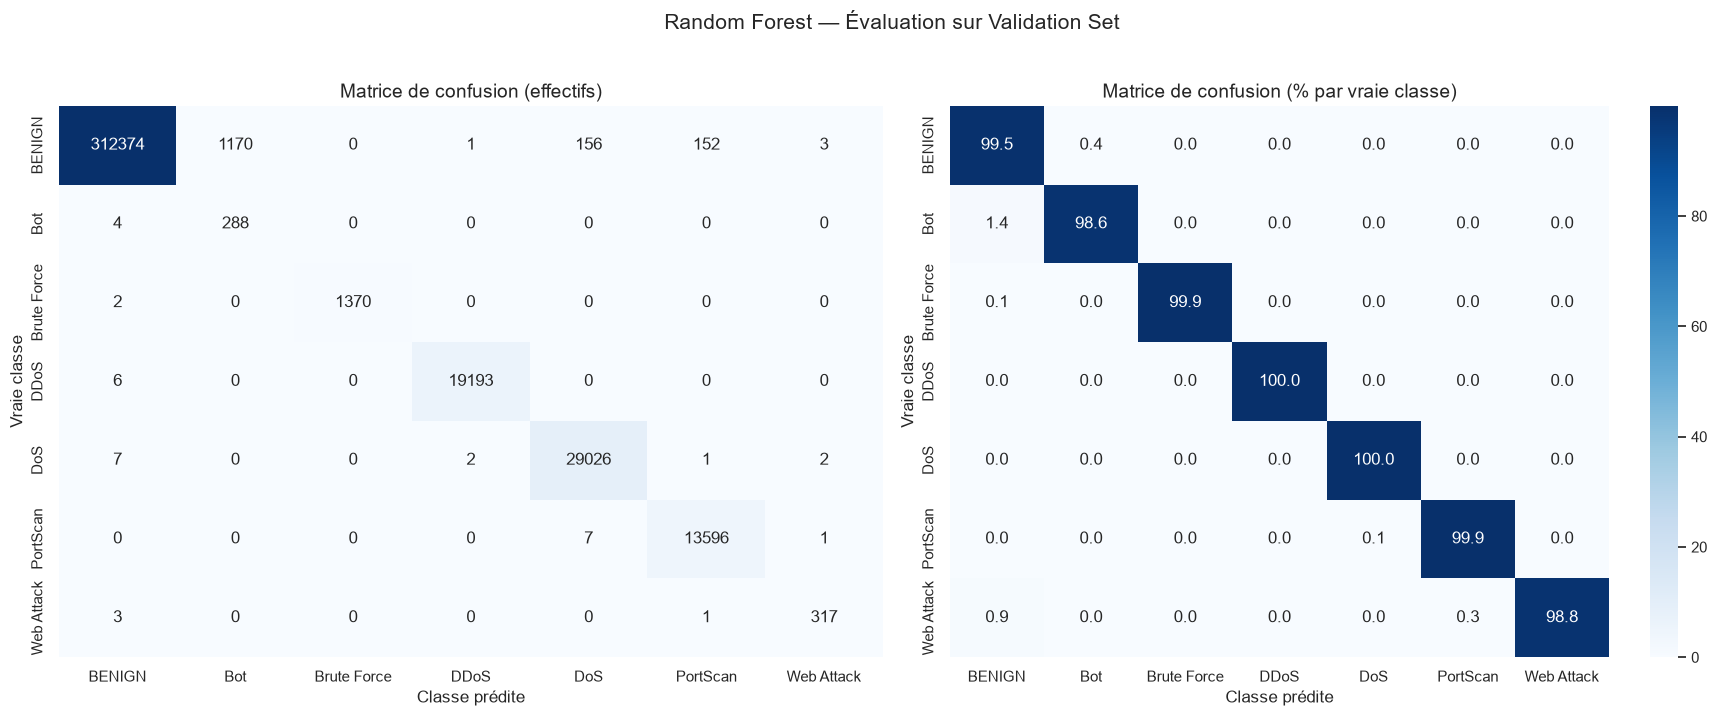


💾 Figure sauvegardée : ..\results\figures/03_rf_confusion_matrix.png


In [10]:
cm = confusion_matrix(y_val, y_val_pred)

# Version normalisée (en %)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

# Figure : 2 sous-plots (brut + normalisé)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Matrice brute
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names,
    ax=axes[0], cbar=False
)
axes[0].set_title('Matrice de confusion (effectifs)', fontsize=14)
axes[0].set_xlabel('Classe prédite')
axes[0].set_ylabel('Vraie classe')

# Matrice normalisée
sns.heatmap(
    cm_norm, annot=True, fmt='.1f', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names,
    ax=axes[1], cbar=True
)
axes[1].set_title('Matrice de confusion (% par vraie classe)', fontsize=14)
axes[1].set_xlabel('Classe prédite')
axes[1].set_ylabel('Vraie classe')

plt.suptitle('Random Forest — Évaluation sur Validation Set', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_FIGURES / '03_rf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n💾 Figure sauvegardée : {RESULTS_FIGURES}/03_rf_confusion_matrix.png')

## 8. Feature Importance (premier aperçu)

### 📚 C'est quoi ?

Le Random Forest peut nous dire **quelles features ont été les plus utiles** pour discriminer les classes. C'est un premier pas vers l'explicabilité — celle qu'on creusera en profondeur avec SHAP en Phase D.

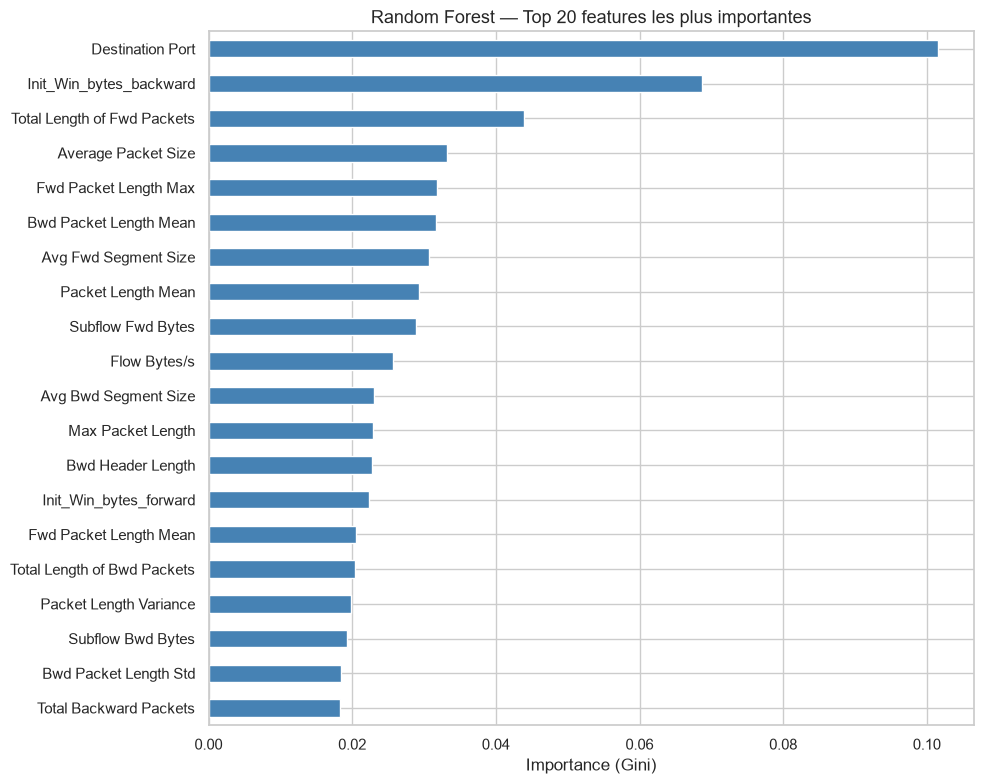


Top 10 features :
  Destination Port                         : 0.1015
  Init_Win_bytes_backward                  : 0.0686
  Total Length of Fwd Packets              : 0.0439
  Average Packet Size                      : 0.0332
  Fwd Packet Length Max                    : 0.0318
  Bwd Packet Length Mean                   : 0.0316
  Avg Fwd Segment Size                     : 0.0307
  Packet Length Mean                       : 0.0294
  Subflow Fwd Bytes                        : 0.0289
  Flow Bytes/s                             : 0.0257


In [11]:
importances = pd.Series(rf.feature_importances_, index=feature_cols)
top_20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 8))
top_20.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title('Random Forest — Top 20 features les plus importantes', fontsize=13)
plt.xlabel('Importance (Gini)')
plt.tight_layout()
plt.savefig(RESULTS_FIGURES / '03_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 features :')
for feat, imp in top_20.head(10).items():
    print(f'  {feat:40s} : {imp:.4f}')

## 9. Sauvegarde du modèle

In [12]:
model_path = RESULTS_MODELS / 'rf_baseline.joblib'
joblib.dump(rf, model_path, compress=3)
size_mb = model_path.stat().st_size / 1024**2
print(f'✅ Modèle sauvegardé : {model_path}')
print(f'   Taille : {size_mb:.1f} MB')

# On sauvegarde aussi la liste des features (utile pour la reproductibilité)
with open(DATA_PROCESSED / 'feature_names.json', 'w') as f:
    json.dump(feature_cols, f, indent=2)

✅ Modèle sauvegardé : ..\results\models\rf_baseline.joblib
   Taille : 6.8 MB


## 🎉 Récapitulatif

Tu viens d'entraîner ton premier modèle de détection d'intrusion. Il a appris à distinguer 7 types de comportements réseau (BENIGN + 6 attaques) à partir de 78 features.

**Ce que tu as produit :**
- Un modèle Random Forest sauvegardé (`rf_baseline.joblib`)
- Un rapport de métriques JSON (`rf_validation_report.json`)
- Deux figures pour le rapport (matrice de confusion + feature importance)
- Des splits train/val/test reproductibles

### Prochaine étape (notebook 04)

**XGBoost optimisé** : on va construire un modèle **bien plus fort** que ce Random Forest, en utilisant Optuna pour le tuning automatique des hyperparamètres. C'est là qu'on va vraiment chercher la performance.